# 40.1 · Image–text embedding alignment

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain image–text embedding alignment using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[38 · Attention Mechanisms](../../38-attention-mechanisms/README.md), [39 · Self-Supervised Learning](../../39-self-supervised-learning/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Vision-language models relate images to text. A dual encoder can compare image and text embeddings for retrieval; a generative model can produce captions or answers. These are different capabilities and require different outputs and evaluation.

## 2. Intuition

An image encoder and text encoder map their inputs into a shared space. Training can increase similarity for paired observations and reduce it for other pairs. The CPU lab learns three synthetic word embeddings and a small image encoder; it demonstrates alignment but has no open-vocabulary language understanding.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 40
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
s_{ij}=\hat v_i^T\hat t_j/\tau
$$

Normalized image embedding v̂i and text embedding t̂j have dot-product similarity, scaled by positive temperature τ. Aligned unit vectors have similarity 1 before scaling. These scores are not calibrated truth probabilities.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
image_embedding = np.array([1.0, 0.0])
text_embeddings = np.array([[1.0, 0.0], [0.0, 1.0]])
scores = text_embeddings @ image_embedding
assert np.allclose(scores, [1.0, 0.0])
print(scores)

[1. 0.]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The local dual encoder learns a closed vocabulary on generated image-label pairs. Pretrained retrieval, captioning and VQA are implemented separately and are never silently substituted for this small experiment.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def vision_language(lesson, seed, amount):
    configure(seed)
    x, y, _ = shape_data(60, seed=seed)
    image_encoder = nn.Sequential(
        nn.Flatten(), nn.Linear(24 * 24, 24), nn.ReLU(), nn.Linear(24, 12)
    )
    text_encoder = nn.Embedding(3, 12)
    optimizer = torch.optim.Adam(
        list(image_encoder.parameters()) + list(text_encoder.parameters()), lr=0.006
    )
    losses = []
    for _ in range(35):
        visual = F.normalize(image_encoder(x), dim=1)
        text = F.normalize(text_encoder(torch.arange(3)), dim=1)
        logits = visual @ text.T / (0.2 * amount)
        loss = F.cross_entropy(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    test, truth, _ = shape_data(12, seed=seed + 1000)
    with torch.no_grad():
        similarity = (
            F.normalize(image_encoder(test), dim=1)
            @ F.normalize(text_encoder(torch.arange(3)), dim=1).T
        )
    labels = ["circle", "square", "triangle"]
    return Result(
        "40 · Learned image-text alignment in a closed vocabulary",
        {
            "Held-out image": test[0, 0].numpy(),
            "Cosine similarity to three words": similarity.numpy(),
        },
        curves={"Alignment cross entropy": losses},
        metrics={
            "held_out_retrieval_accuracy": float((similarity.argmax(1) == truth).float().mean()),
            "retrieved_word": labels[int(similarity[0].argmax())],
            "vocabulary": labels,
        },
        notes="A trainable three-token dual encoder teaches alignment. It is not CLIP, free-form captioning or general VQA. Those use explicit optional pretrained adapters.",
    )

{
  "held_out_retrieval_accuracy": 0.8333333134651184,
  "retrieved_word": "circle",
  "vocabulary": [
    "circle",
    "square",
    "triangle"
  ]
}
A trainable three-token dual encoder teaches alignment. It is not CLIP, free-form captioning or general VQA. Those use explicit optional pretrained adapters.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import attention

display(Code(inspect.getsource(attention), language="python"))

def attention(q, k, v, mask=None):
    """Scaled dot-product attention, optionally masking prohibited pairs."""
    scores = np.asarray(q) @ np.asarray(k).T / np.sqrt(np.asarray(q).shape[-1])
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax(scores)
    return weights @ v, weights

## 8. Experiment

Add a visually similar distractor prompt to a candidate set and inspect score changes. Evaluate retrieval rank rather than assuming a fixed probability meaning.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "held_out_retrieval_accuracy": 0.8333333134651184,
    "retrieved_word": "circle",
    "vocabulary": [
      "circle",
      "square",
      "triangle"
    ]
  },
  "second_seed": {
    "held_out_retrieval_accuracy": 0.5833333134651184,
    "retrieved_word": "circle",
    "vocabulary": [
      "circle",
      "square",
      "triangle"
    ]
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

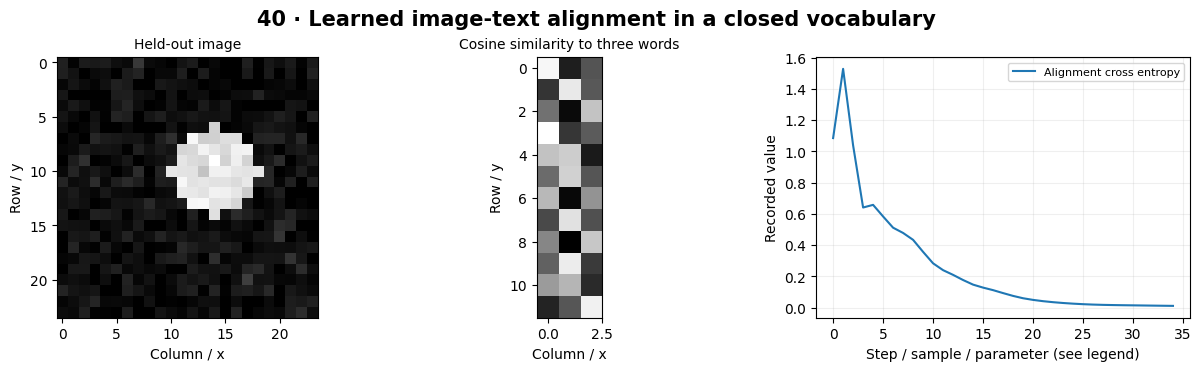

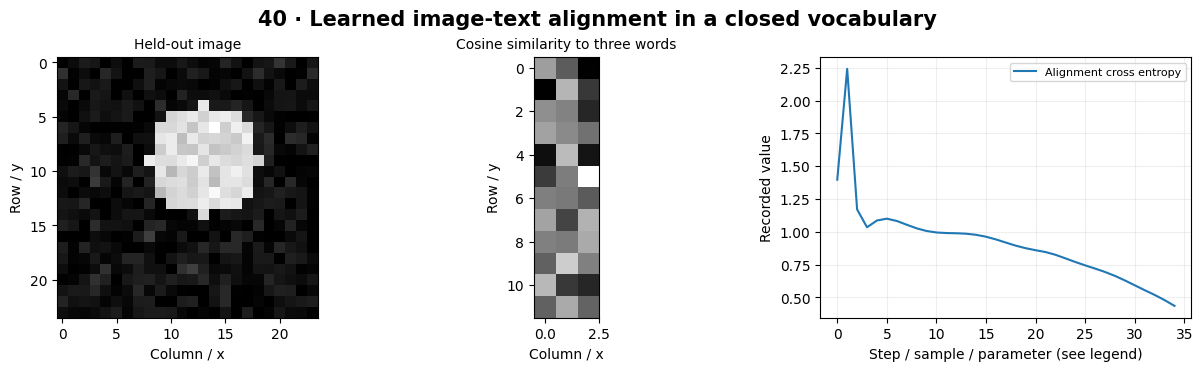

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Image-Text Search**. Measure retrieval and prompt sensitivity with documented model licenses. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A plausible caption may hallucinate objects. An embedding similarity cannot establish a person’s identity, intent or protected traits.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Add a visually similar distractor prompt to a candidate set and inspect score changes. Evaluate retrieval rank rather than assuming a fixed probability meaning.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build an image search tool with a documented candidate set, retrieval metrics and an error gallery for ambiguous prompts.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

An image encoder and text encoder map their inputs into a shared space. Training can increase similarity for paired observations and reduce it for other pairs. The CPU lab learns three synthetic word embeddings and a small image encoder; it demonstrates alignment but has no open-vocabulary language understanding.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Retrieval and zero-shot candidate scoring** in this chapter.

[Primary reference](https://arxiv.org/abs/2103.00020) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)